In [1]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


## 1. DATA preprocessing

In [2]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final criteria
yr_strt=1985;yr_end=2012
period=yr_end-yr_strt; miss_prc=8
gauge_final=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_final.reset_index(drop=True,inplace=True)

stn=gauge_final['GaugeID'].values[35]

for g,stn in enumerate(gauge_final['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True) 
    nan_years = data1.groupby(data1.index.year)['Streamflow (cumecs)'].apply(lambda x: x.isna().all())
    nan_years=nan_years[nan_years].index.to_list()
    data1=data1.interpolate(method='linear')
    data1.to_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv') 
    



# 2. Poisson Check


In [347]:
th=70
data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 
th_value=np.percentile(data1['Streamflow (cumecs)'],th)

POT = data1[data1['Streamflow (cumecs)'] > th_value]
POT["Date"] = POT.index

# Independent criteria  #Minimum 30 days gap
IC=pd.Timedelta(days=20)
#POT=POT[POT["Date"].diff().fillna(pd.Timedelta(days=50)) > IC]

data1["Exceedance"] = 0
data1.loc[POT.index, "Exceedance"] = 1

np.sum(data1["Exceedance"]==1)

#data1[data1['Streamflow (cumecs)'] > th_value]
#data1.to_csv(r'2_Analysis\2_Distribution_check\Outputs\ss.csv', index=True)

#th_value
#POT[POT["Date"].diff().fillna(pd.Timedelta(days=50)) > IC]

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_3108\3103425013.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  POT["Date"] = POT.index


3397

In [ ]:
from scipy.stats import poisson, chisquare, kstest

stn=gauge_final['GaugeID'].values[0]
thr=[99.9,98,95,90,60,40] 


# Defining storing variable 
result_ks=pd.DataFrame(data=gauge_final[['Station','Latitude','Longitude']].to_numpy(),columns=['Station','Latitude','Longitude'],index=gauge_final['GaugeID'])

result_mean = result_ks.copy()
result_chi = result_ks.copy()

#for g,stn in enumerate(gauge_final['GaugeID'].values):


# Poisson Test

for s,stn in enumerate(gauge_final['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) 

    for t,th in enumerate(thr):


        th_value=np.percentile(data1['Streamflow (cumecs)'],th)

        POT = data1[data1['Streamflow (cumecs)'] > th_value]
        POT["Date"] = POT.index

        # Independent criteria  #Minimum 30 days gap
        #IC=pd.Timedelta(days=30)
        #POT=POT[POT["Date"].diff().fillna(pd.Timedelta(days=50)) > IC]

        data1["Exceedance"] = 0
        data1.loc[POT.index, "Exceedance"] = 1

        flood_counts=data1["Exceedance"].groupby(data1.index.year).sum()

        # Estimate Poisson parameter (mean of observed counts)
        lambda_est = np.mean(flood_counts)

        # Kolmogorov-Smirnov (KS) Test
        ks_stat, ks_p = kstest(flood_counts, poisson.cdf, args=(lambda_est,))

        result_ks.loc[stn,f"P{th}"] = ks_p
        result_mean.loc[stn,f"P{th}"] = lambda_est
    



C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_3108\4037336165.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  POT["Date"] = POT.index
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_3108\4037336165.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  POT["Date"] = POT.index
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_3108\4037336165.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

# 2 PLOTs

### 2.1 Map

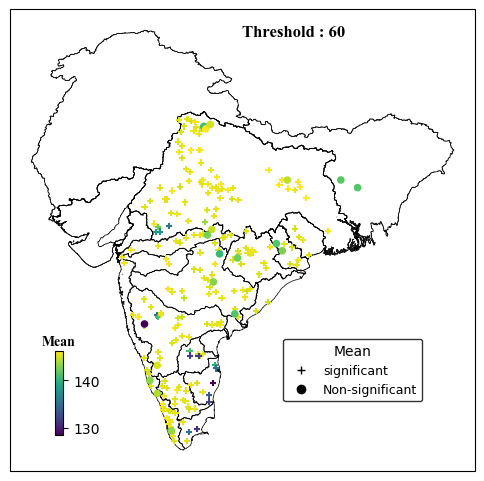

: 

In [ ]:
import matplotlib.lines as mlines

perc=[f"P{thr[i]}" for i in range(len(thr))]

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

p=perc[4]



fig,ax1 = plt.subplots(1,1,figsize=(6,6),subplot_kw={'projection': ccrs.PlateCarree()})

south_asia.plot(ax=ax1,color='none',edgecolor='black',linewidth=0.55,alpha=0.9)


bins = [0, 0.05 ,2]
marker1 = ['+', 'o']
result_ks['marker'] = pd.cut(result_ks[p], bins=bins, labels=marker1)
scatter_plots = []
for marker_type, label in zip(marker1, ["significant", "Non-significant"]):
    subset = result_ks[result_ks['marker'] == marker_type]
    sc=ax1.scatter(subset['Longitude'],subset['Latitude'],c=result_mean.loc[subset.index,p],cmap='viridis',marker=marker_type,s=20)
    scatter_plots.append(mlines.Line2D([], [], color='black', marker=marker_type, linestyle='None', markersize=6, label=label))



cbar_ax = fig.add_axes([0.2, 0.17, 0.014, 0.14])
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.ax.set_xlabel('Mean', fontsize=10, fontname='Times New Roman',weight='bold')
cbar.ax.xaxis.set_label_position('top')


ax1.text(0.50, 0.95, f'Threshold : {p[1:]}', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
transform=ax1.transAxes, ha='left', va='center')


ax1.legend(handles=scatter_plots, title="Mean", title_fontsize=10, fontsize=9, frameon=True, edgecolor='black', bbox_to_anchor=(0.9, 0.3))



#plt.savefig(fr'22_Analysis\2_Distribution_check\Outputs\{p}', bbox_inches='tight',dpi=1000)

# FUNCTIONS

### 1. Station visualization

In [6]:

def Station_Map(data,condition):

    #data=pd.read_csv(r"3_Data\Data_p\2_Station\1_Streamflow_data\data.csv")
    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')
 
    fig, ax1 = plt.subplots(1, 1, figsize=(6,6), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]

    c1=np.repeat(['Blue'],len(data['Latitude']))
    sc=ax1.scatter(data['Longitude'],data['Latitude'],c='firebrick',s=13,edgecolor='black')

    ax1.text(0.50, 0.95, 'Stations : Full', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    ax1.text(0.5, 0.9, f'No of Station : {len(data)}' , fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')


